# 01 — EDA: Transaction Patterns & Fraud Typologies

Explore the synthetic transaction dataset:
1. Class imbalance
2. Feature distributions by fraud status
3. Fraud typology breakdown
4. Correlation heatmap

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from src.data.generator import generate_transactions, FEATURE_COLS
sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
df = generate_transactions(n=50_000, fraud_rate=0.02, seed=42)
print(f"Dataset: {len(df):,} transactions | Fraud rate: {df['is_fraud'].mean():.2%}")
df.head()

Dataset: 50,000 transactions | Fraud rate: 2.00%


,transaction_id,amount,hour,day_of_week,n_txn_last_1h,n_txn_last_24h,country_risk,is_new_payee,channel,balance_before,is_fraud,amount_to_balance,is_round_amount,log_amount,is_off_hours,velocity_ratio,high_risk_new_payee
0,TXN0000000,277.242990,21,3,0,6,0,0,0,5696.889671,0,0.048657,0,5.628495,0,0.000000,0
1,TXN0000001,88.610564,20,4,0,2,0,0,2,7212.085784,0,0.012285,0,4.495473,0,0.000000,0
2,TXN0000002,67.074422,15,4,2,2,0,0,1,37081.133641,0,0.001809,0,4.220602,0,0.666667,0
3,TXN0000003,119.609736,15,3,1,6,0,0,0,1147.931062,0,0.104105,0,4.792560,0,0.142857,0
4,TXN0000004,152.062889,10,1,2,7,0,0,1,7261.703566,0,0.020938,0,5.030849,0,0.250000,0


## Step 1 — Class Imbalance

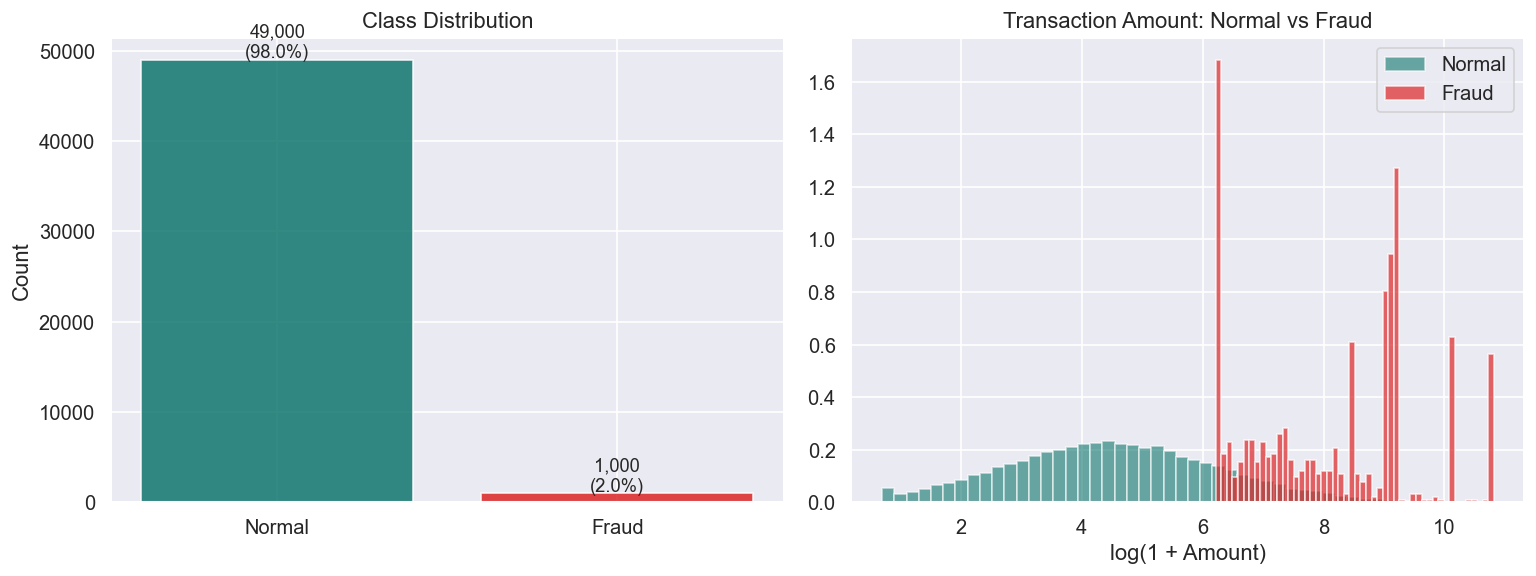

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df['is_fraud'].value_counts()
axes[0].bar(['Normal', 'Fraud'], counts.values, color=['#0f766e','#dc2626'], alpha=0.85)
for i, v in enumerate(counts.values):
    axes[0].text(i, v+200, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=11)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Amount distribution
axes[1].hist(np.log1p(df[df['is_fraud']==0]['amount']), bins=50, alpha=0.6, color='#0f766e', label='Normal', density=True)
axes[1].hist(np.log1p(df[df['is_fraud']==1]['amount']), bins=50, alpha=0.7, color='#dc2626', label='Fraud', density=True)
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_title('Transaction Amount: Normal vs Fraud')
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2 — Fraud Typology Analysis

Fraud typology breakdown:
typology
Structuring     217
Round Amount    211
Geo Risk        204
Velocity        200
Other           152
Off-Hours        16


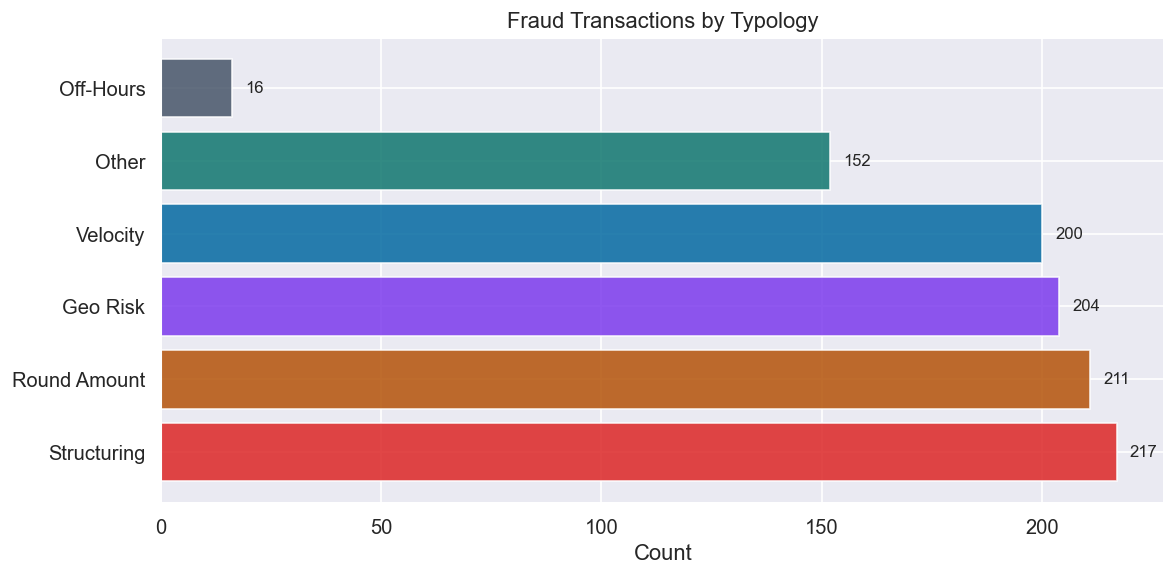

In [3]:
# Approximate typology assignment based on feature signatures
def label_typology(row):
    if 8000 <= row['amount'] < 10000 and row['is_fraud']:  return 'Structuring'
    if row.get('is_round_amount',0) and row['amount']>=5000 and row['is_fraud']: return 'Round Amount'
    if row['n_txn_last_1h'] >= 8 and row['is_fraud']:      return 'Velocity'
    if row['country_risk'] == 2 and row['is_fraud']:        return 'Geo Risk'
    if row['is_off_hours'] and row['amount']>=5000 and row['is_fraud']: return 'Off-Hours'
    if row['is_fraud']:                                      return 'Other'
    return 'Normal'

df['typology'] = df.apply(label_typology, axis=1)
fraud_types = df[df['is_fraud']==1]['typology'].value_counts()
print("Fraud typology breakdown:")
print(fraud_types.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#dc2626','#b45309','#7c3aed','#0369a1','#0f766e','#475569']
bars = ax.barh(fraud_types.index, fraud_types.values, color=colours[:len(fraud_types)], alpha=0.85)
for bar in bars:
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
            str(bar.get_width()), va='center', fontsize=10)
ax.set_xlabel('Count')
ax.set_title('Fraud Transactions by Typology')
plt.tight_layout()
plt.savefig('../outputs/figures/01_typology_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Feature Correlation Heatmap

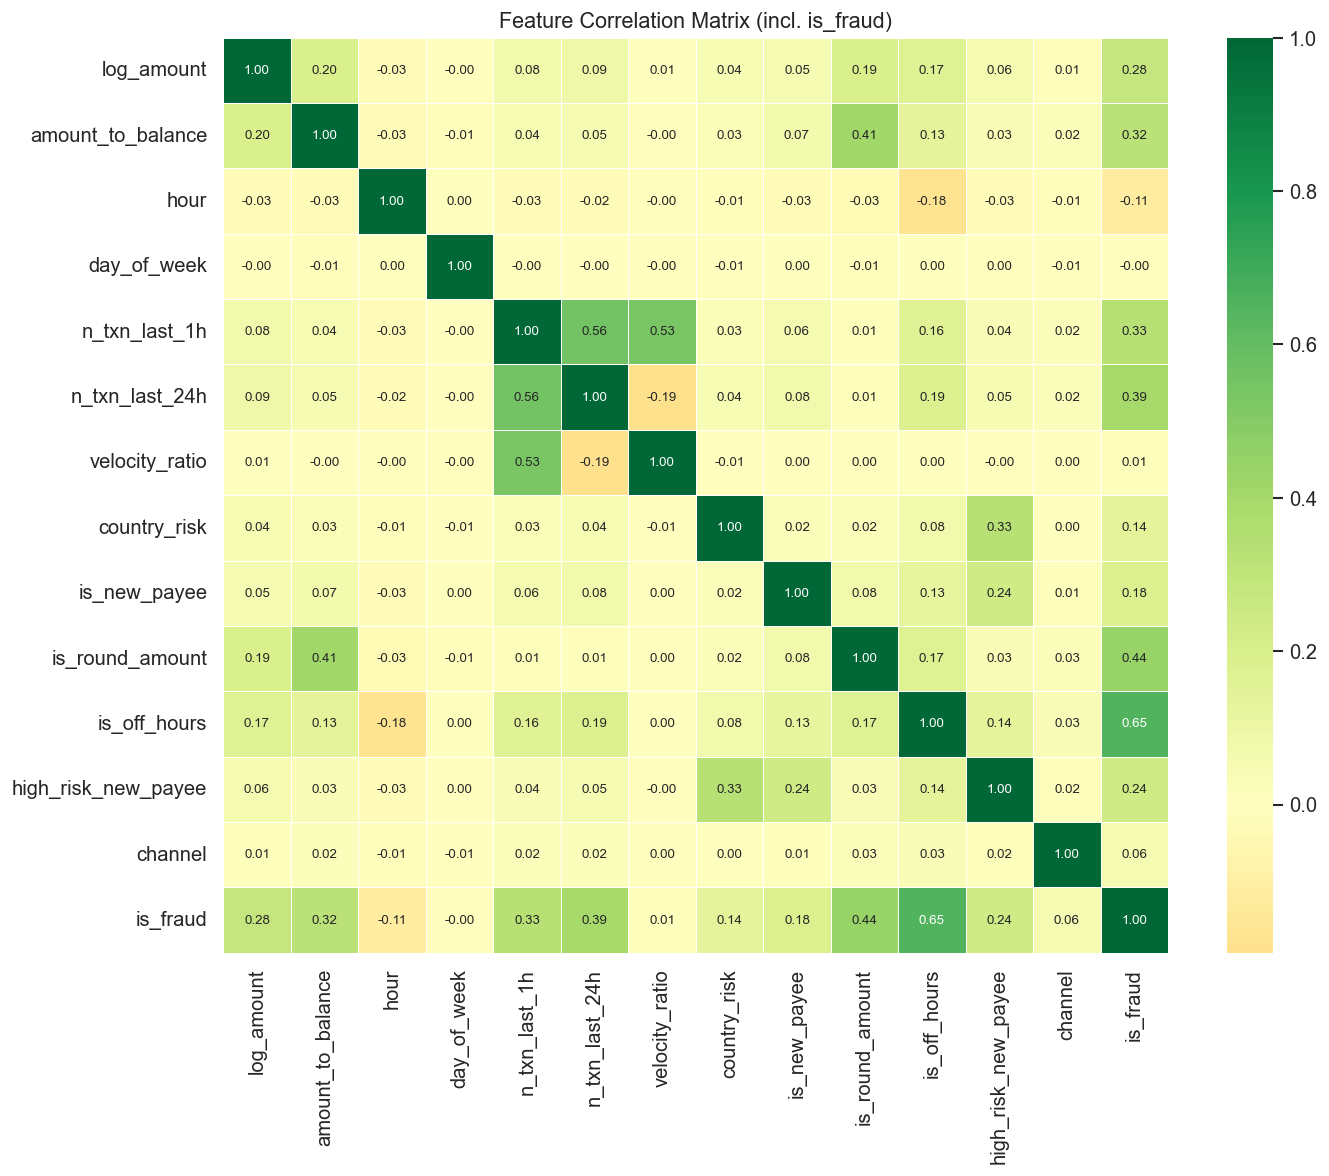


Top correlations with is_fraud:
is_off_hours           0.651198
is_round_amount        0.443836
n_txn_last_24h         0.394235
n_txn_last_1h          0.332097
amount_to_balance      0.316764
log_amount             0.278915
high_risk_new_payee    0.242520
is_new_payee           0.183455


In [4]:
corr = df[FEATURE_COLS + ['is_fraud']].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (incl. is_fraud)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop correlations with is_fraud:")
print(corr['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False).head(8).to_string())